# Run Set Analysis

For each of the 4 ``{experiment_type} x {ai_type}`` groups, show
1. Consistency and variance across runs for 8 metrics (wall time, CPU energy, GPU energy, LLM calls, tokens in, tokens out, tool calls, acceptance rate), as a plot and as a run-level summary table (mean/median/std/min/max/CV);
2. The CPU vs. GPU energy split, summarized across all four groups.


In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from great_tables import GT

from create_polar_dataframe import build_run_level_df, load_all_runs

sns.set_theme(style='whitegrid')

In [2]:
GROUPS = [
    ('passive', 'traditional'),
    ('passive', 'agent'),
    ('active', 'traditional'),
    ('active', 'agent'),
]

LABELS = {
    'wall_time_seconds': 'Wall Time (seconds)',
    'cpu_energy_joules': 'CPU Energy (Joules)',
    'gpu_energy_joules': 'GPU Energy (Joules)',
    'total_llm_calls': 'Total LLM Calls',
    'total_tokens_in': 'Total Tokens In',
    'total_tokens_out': 'Total Tokens Out',
    'total_tool_calls': 'Total Tool Calls',
    'acceptance_rate': 'Acceptance Rate',
}

In [3]:
def analyze_consistency(run_df):
    params = list(LABELS.keys())
    runs = run_df['run_index'].to_list()

    fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))

    for ax, param in zip(axes.flat, params):
        mean, std = run_df[param].mean(), run_df[param].std()

        ax.scatter(runs, run_df[param].to_list(), s=70, zorder=3)
        ax.axhline(mean, linestyle='--', linewidth=1, zorder=1)

        ax.set_title(LABELS[param], fontsize=12, fontweight='bold')
        ax.set_xlabel('Runs')
        ax.set_xticks([])
        ax.grid(True, alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        label = (
            f'Mean: {mean:,.3g}\nCV: {std / mean * 100:.2f}%'
            if mean
            else 'Constant\n(no variation)'
        )
        ax.text(
            0.97,
            0.03,
            label,
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=9.5,
            bbox=dict(
                boxstyle='round,pad=0.35',
                facecolor='white',
                edgecolor='black',
                alpha=0.85,
            ),
        )

    fig.suptitle(
        'Run-to-Run Consistency', fontsize=14, fontweight='bold', y=1.00
    )
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))

In [4]:
def analyze_cpu_vs_gpu_energy(run_df, ax, subtitle):
    cpu_mean = run_df['cpu_energy_joules'].mean()
    gpu_mean = run_df['gpu_energy_joules'].mean()
    total = cpu_mean + gpu_mean

    ax.pie(
        [cpu_mean, gpu_mean],
        labels=['CPU Energy', 'GPU Energy'],
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75,
        textprops={'fontsize': 11},
    )
    ax.axis('equal')

    ax.text(
        0,
        -1.25,
        f'CPU: {cpu_mean:,.0f} J   |   GPU: {gpu_mean:,.0f} J   |   Total: {total:,.0f} J',
        ha='center',
        fontsize=10,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='black',
            alpha=0.85,
        ),
    )

    ax.set_title(subtitle, fontsize=13, fontweight='bold')

In [5]:
def run_level_summary_table(run_df, metrics=None):
    """Mean/median/std/min/max/CV per run-level metric (mirrors the
    "Run-level summary" table in parse_results.py), returned as a GT table.
    great_tables formats the numbers directly from the numeric run_df, so
    no manual to_numpy()/string formatting is needed; call `.as_latex()`
    on the result to get the LaTeX source for the table.
    """
    metrics = metrics or list(LABELS.keys())
    rows = []
    for m in metrics:
        s = run_df[m]
        mean, std = s.mean(), s.std()
        rows.append(
            {
                'Metric': LABELS[m],
                'mean': mean,
                'median': s.median(),
                'std': std,
                'min': s.min(),
                'max': s.max(),
                'cv': std / mean if mean else None,
            }
        )
    stats_df = pl.DataFrame(rows)

    stat_cols = ['mean', 'median', 'std', 'min', 'max', 'cv']
    return (
        GT(stats_df)
        .fmt_scientific(columns=stat_cols, n_sigfig=3)
        .cols_label(
            mean='Mean',
            median='Median',
            std='Std. Dev.',
            min='Min',
            max='Max',
            cv='CV',
        )
    )

## Passive / Traditional


\begin{table}[!t]


\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lrrrrrr}
\toprule
Metric & Mean & Median & Std. Dev. & Min & Max & CV \\ 
\midrule\addlinespace[2.5pt]
Wall Time (seconds) & 5.16 $\times$ 10\textsuperscript{3} & 5.13 $\times$ 10\textsuperscript{3} & 1.39 $\times$ 10\textsuperscript{2} & 4.97 $\times$ 10\textsuperscript{3} & 5.47 $\times$ 10\textsuperscript{3} & 2.70 $\times$ 10\textsuperscript{-2} \\
CPU Energy (Joules) & 7.35 $\times$ 10\textsuperscript{5} & 7.30 $\times$ 10\textsuperscript{5} & 2.06 $\times$ 10\textsuperscript{4} & 7.06 $\times$ 10\textsuperscript{5} & 7.84 $\times$ 10\textsuperscript{5} & 2.81 $\times$ 10\textsuperscript{-2} \\
GPU Energy (Joules) & 2.76 $\times$ 10\textsuperscript{6} & 2.74 $\times$ 10\textsuperscript{6} & 8.16 $\times$ 10\textsuperscript{4} & 2.65 $\times$ 10\textsuperscript{6} & 2.93 $\times$ 10\textsuperscript{6} & 2.95 $\times$ 10\textsuperscript{-2} \\
Total LLM Calls & 2.89 $\times$ 

Metric,Mean,Median,Std. Dev.,Min,Max,CV
Wall Time (seconds),5.16 × 103,5.13 × 103,1.39 × 102,4.97 × 103,5.47 × 103,2.70 × 10−2
CPU Energy (Joules),7.35 × 105,7.30 × 105,2.06 × 104,7.06 × 105,7.84 × 105,2.81 × 10−2
GPU Energy (Joules),2.76 × 106,2.74 × 106,8.16 × 104,2.65 × 106,2.93 × 106,2.95 × 10−2
Total LLM Calls,2.89 × 102,2.89 × 102,4.71,2.80 × 102,3.00 × 102,1.63 × 10−2
Total Tokens In,7.27 × 105,7.10 × 105,4.82 × 104,6.71 × 105,8.37 × 105,6.63 × 10−2
Total Tokens Out,7.64 × 104,7.62 × 104,2.27 × 103,7.36 × 104,8.14 × 104,2.97 × 10−2
Total Tool Calls,0.00,0.00,0.00,0.00,0.00,None
Acceptance Rate,9.93 × 10−1,9.94 × 10−1,4.13 × 10−3,9.80 × 10−1,9.96 × 10−1,4.16 × 10−3


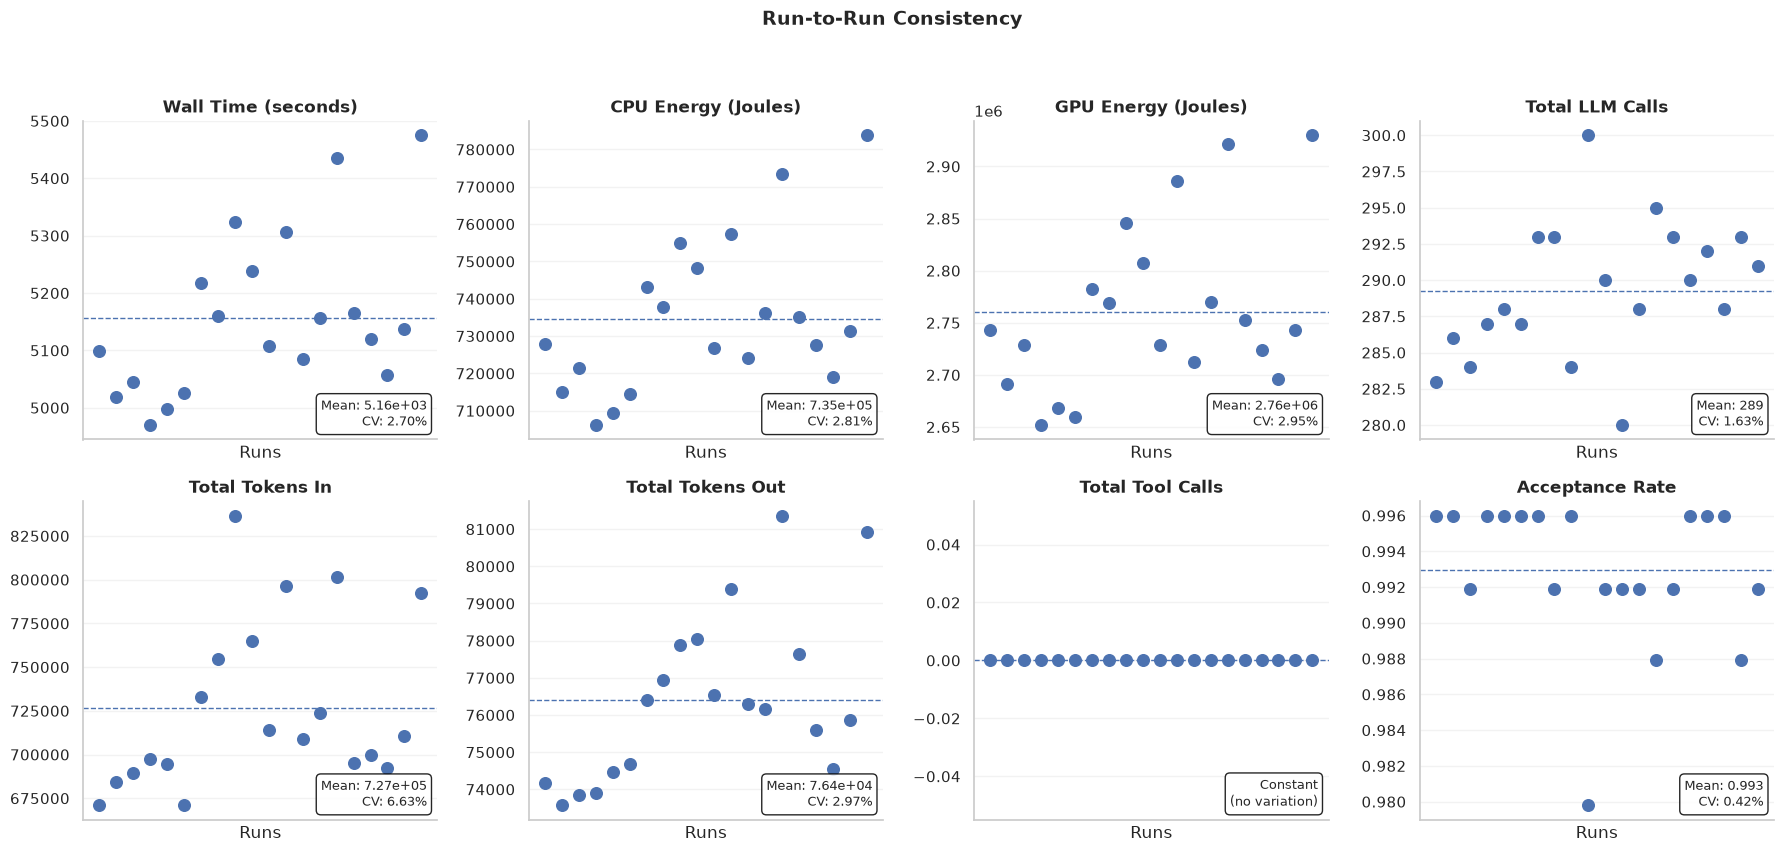

In [6]:
all_runs = load_all_runs('passive', 'traditional')
run_df_p_t = build_run_level_df(all_runs)
analyze_consistency(run_df_p_t)

summary_tbl = run_level_summary_table(run_df_p_t)
print(summary_tbl.as_latex())
summary_tbl

## Passive / Agent


\begin{table}[!t]


\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lrrrrrr}
\toprule
Metric & Mean & Median & Std. Dev. & Min & Max & CV \\ 
\midrule\addlinespace[2.5pt]
Wall Time (seconds) & 1.05 $\times$ 10\textsuperscript{4} & 8.43 $\times$ 10\textsuperscript{3} & 5.16 $\times$ 10\textsuperscript{3} & 7.21 $\times$ 10\textsuperscript{3} & 2.45 $\times$ 10\textsuperscript{4} & 4.92 $\times$ 10\textsuperscript{-1} \\
CPU Energy (Joules) & 1.53 $\times$ 10\textsuperscript{6} & 1.22 $\times$ 10\textsuperscript{6} & 7.51 $\times$ 10\textsuperscript{5} & 1.05 $\times$ 10\textsuperscript{6} & 3.56 $\times$ 10\textsuperscript{6} & 4.92 $\times$ 10\textsuperscript{-1} \\
GPU Energy (Joules) & 5.99 $\times$ 10\textsuperscript{6} & 4.80 $\times$ 10\textsuperscript{6} & 2.97 $\times$ 10\textsuperscript{6} & 4.10 $\times$ 10\textsuperscript{6} & 1.40 $\times$ 10\textsuperscript{7} & 4.96 $\times$ 10\textsuperscript{-1} \\
Total LLM Calls & 1.99 $\times$ 

Metric,Mean,Median,Std. Dev.,Min,Max,CV
Wall Time (seconds),1.05 × 104,8.43 × 103,5.16 × 103,7.21 × 103,2.45 × 104,4.92 × 10−1
CPU Energy (Joules),1.53 × 106,1.22 × 106,7.51 × 105,1.05 × 106,3.56 × 106,4.92 × 10−1
GPU Energy (Joules),5.99 × 106,4.80 × 106,2.97 × 106,4.10 × 106,1.40 × 107,4.96 × 10−1
Total LLM Calls,1.99 × 101,2.00 × 101,3.08 × 10−1,1.90 × 101,2.00 × 101,1.55 × 10−2
Total Tokens In,4.78 × 106,4.64 × 106,8.73 × 105,3.10 × 106,6.64 × 106,1.83 × 10−1
Total Tokens Out,8.60 × 104,8.49 × 104,1.20 × 104,5.96 × 104,1.10 × 105,1.40 × 10−1
Total Tool Calls,2.91 × 102,2.86 × 102,3.30 × 101,2.21 × 102,3.78 × 102,1.14 × 10−1
Acceptance Rate,9.92 × 10−1,1.00,1.83 × 10−2,9.50 × 10−1,1.00,1.85 × 10−2


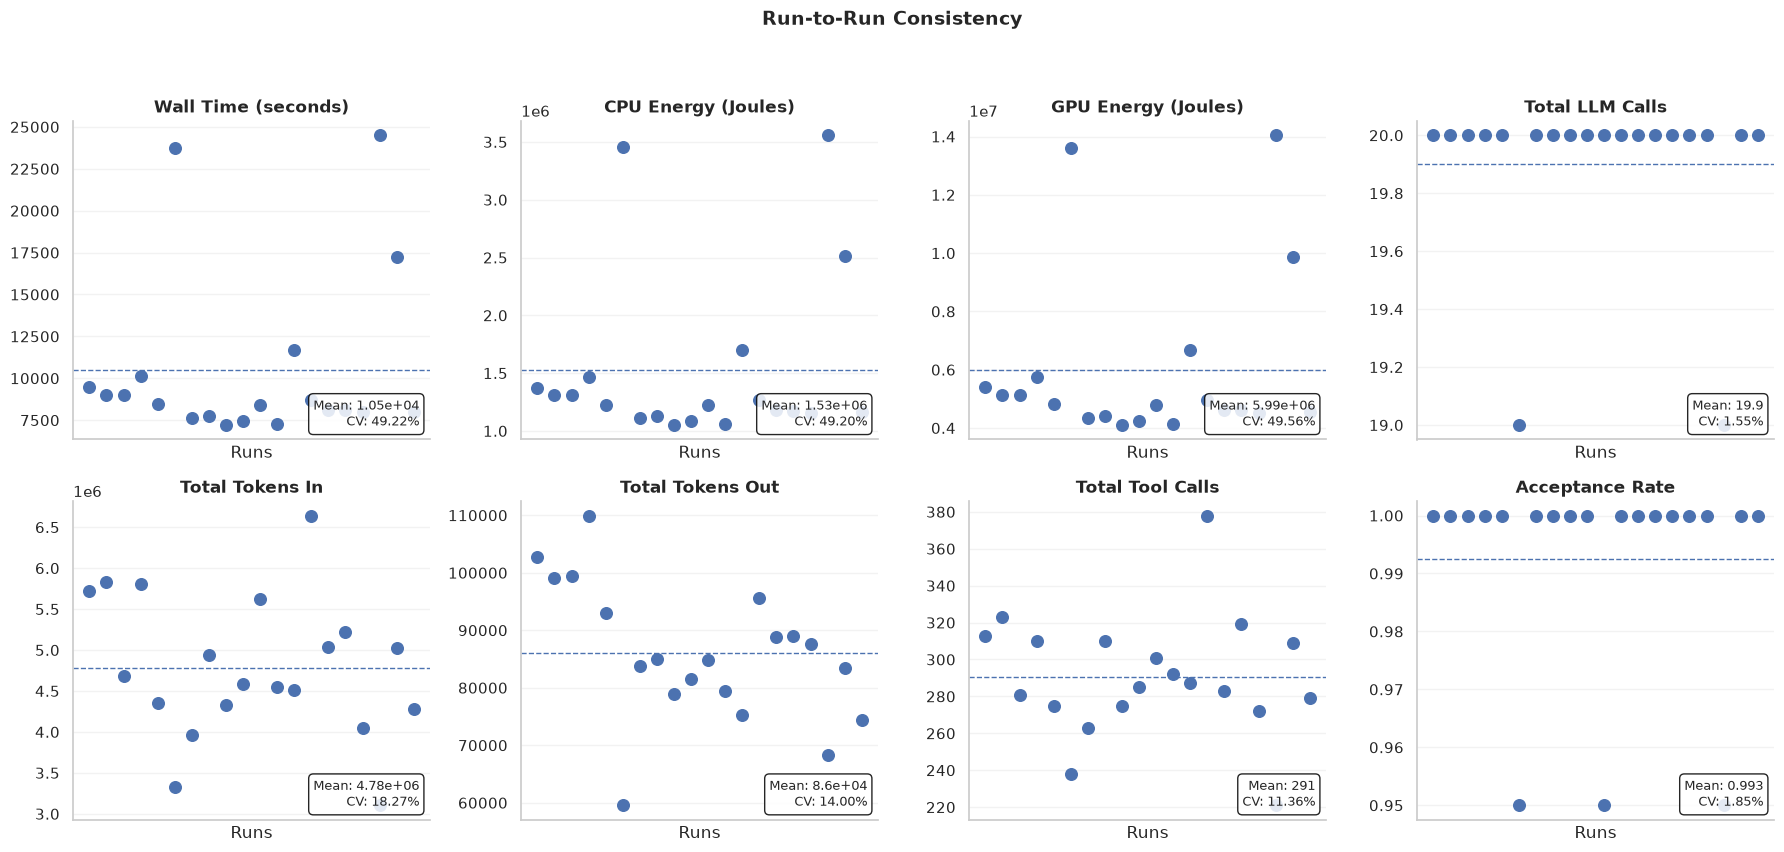

In [7]:
all_runs = load_all_runs('passive', 'agent')
run_df_p_a = build_run_level_df(all_runs)
analyze_consistency(run_df_p_a)

summary_tbl = run_level_summary_table(run_df_p_a)
print(summary_tbl.as_latex())
summary_tbl

## Active / Traditional


\begin{table}[!t]


\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lrrrrrr}
\toprule
Metric & Mean & Median & Std. Dev. & Min & Max & CV \\ 
\midrule\addlinespace[2.5pt]
Wall Time (seconds) & 4.50 $\times$ 10\textsuperscript{3} & 4.50 $\times$ 10\textsuperscript{3} & 7.63 $\times$ 10\textsuperscript{1} & 4.37 $\times$ 10\textsuperscript{3} & 4.66 $\times$ 10\textsuperscript{3} & 1.70 $\times$ 10\textsuperscript{-2} \\
CPU Energy (Joules) & 6.11 $\times$ 10\textsuperscript{5} & 6.10 $\times$ 10\textsuperscript{5} & 1.07 $\times$ 10\textsuperscript{4} & 5.92 $\times$ 10\textsuperscript{5} & 6.30 $\times$ 10\textsuperscript{5} & 1.75 $\times$ 10\textsuperscript{-2} \\
GPU Energy (Joules) & 2.17 $\times$ 10\textsuperscript{6} & 2.17 $\times$ 10\textsuperscript{6} & 4.15 $\times$ 10\textsuperscript{4} & 2.10 $\times$ 10\textsuperscript{6} & 2.25 $\times$ 10\textsuperscript{6} & 1.91 $\times$ 10\textsuperscript{-2} \\
Total LLM Calls & 1.31 $\times$ 

Metric,Mean,Median,Std. Dev.,Min,Max,CV
Wall Time (seconds),4.50 × 103,4.50 × 103,7.63 × 101,4.37 × 103,4.66 × 103,1.70 × 10−2
CPU Energy (Joules),6.11 × 105,6.10 × 105,1.07 × 104,5.92 × 105,6.30 × 105,1.75 × 10−2
GPU Energy (Joules),2.17 × 106,2.17 × 106,4.15 × 104,2.10 × 106,2.25 × 106,1.91 × 10−2
Total LLM Calls,1.31 × 102,1.31 × 102,1.38,1.28 × 102,1.34 × 102,1.05 × 10−2
Total Tokens In,4.71 × 105,4.66 × 105,1.63 × 104,4.50 × 105,5.21 × 105,3.47 × 10−2
Total Tokens Out,3.67 × 104,3.68 × 104,7.78 × 102,3.55 × 104,3.79 × 104,2.12 × 10−2
Total Tool Calls,0.00,0.00,0.00,0.00,0.00,None
Acceptance Rate,9.76 × 10−1,9.73 × 10−1,4.40 × 10−3,9.73 × 10−1,9.82 × 10−1,4.51 × 10−3


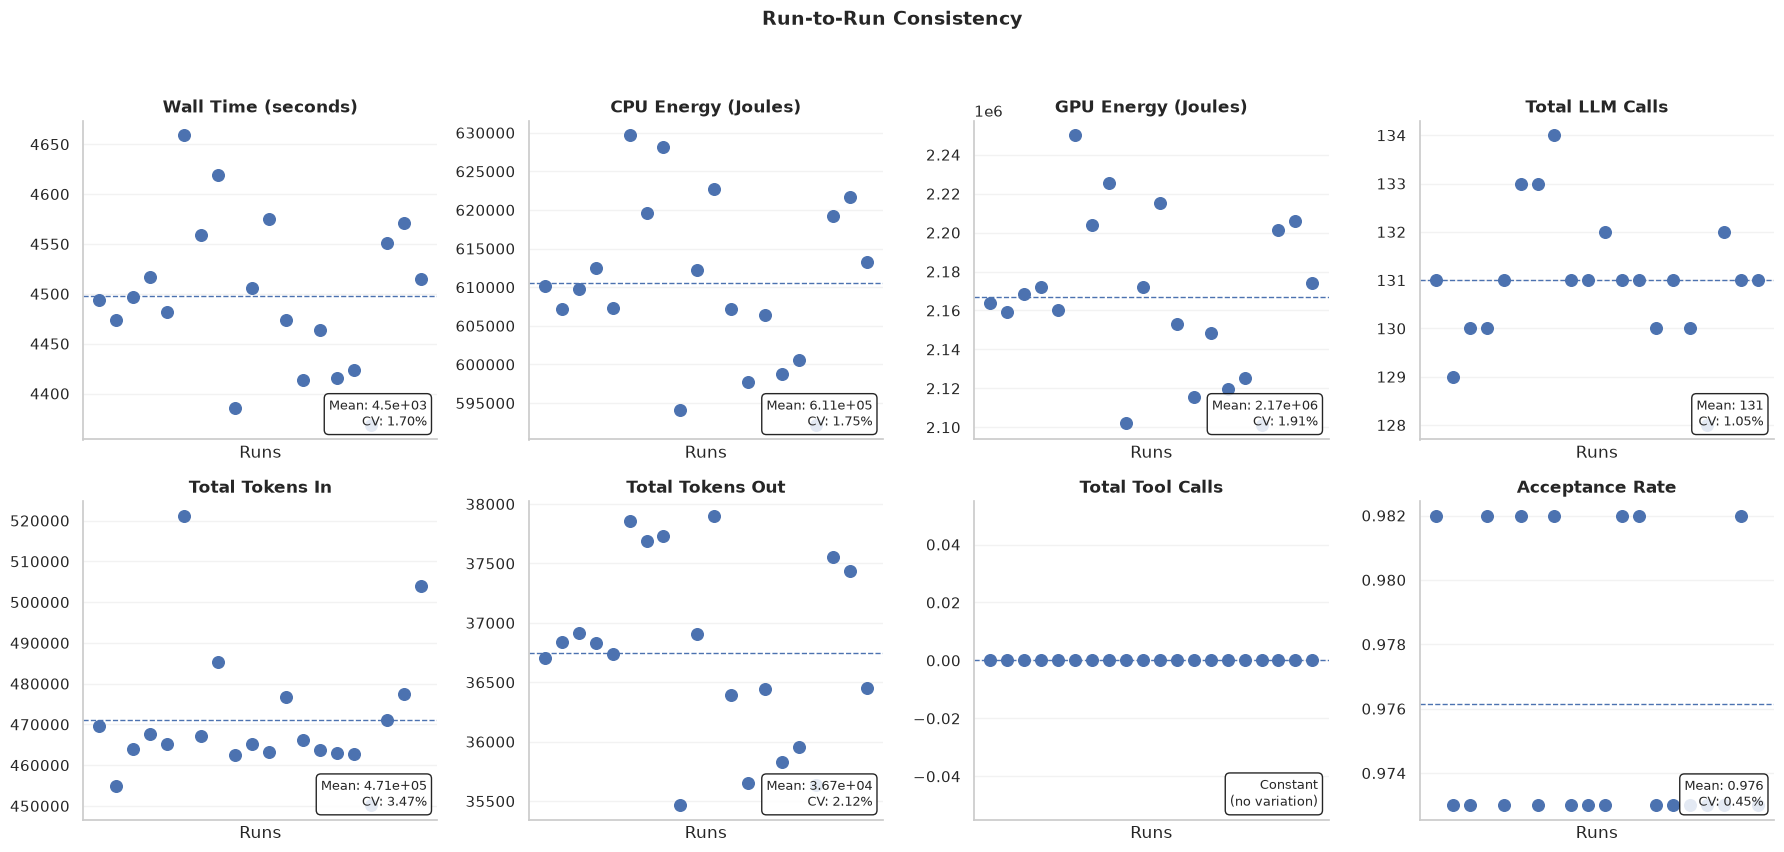

In [8]:
all_runs = load_all_runs('active', 'traditional')
run_df_a_t = build_run_level_df(all_runs)
analyze_consistency(run_df_a_t)

summary_tbl = run_level_summary_table(run_df_a_t)
print(summary_tbl.as_latex())
summary_tbl

## Active / Agent


In [9]:
all_runs = load_all_runs('active', 'agent')
run_df_a_a = build_run_level_df(all_runs)
analyze_consistency(run_df_a_a)

summary_tbl = run_level_summary_table(run_df_a_a)
print(summary_tbl.as_latex())
summary_tbl

ColumnNotFoundError: "per_unit_results" not found

## Summary


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 7))

analyze_cpu_vs_gpu_energy(
    run_df_p_t,
    ax=axes[0],
    subtitle='Passive / Traditional',
)

analyze_cpu_vs_gpu_energy(
    run_df_p_a,
    ax=axes[1],
    subtitle='Passive / Agent',
)

analyze_cpu_vs_gpu_energy(
    run_df_a_t,
    ax=axes[2],
    subtitle='Active / Traditional',
)

analyze_cpu_vs_gpu_energy(
    run_df_a_a,
    ax=axes[3],
    subtitle='Active / Agent',
)

fig.suptitle(
    'CPU vs GPU Share of Total Energy Consumption by Group',
    fontsize=15,
    fontweight='bold',
    y=1.03,
)
fig.tight_layout()

In [ ]:
outcome_summaries = {}
for experiment_type, ai_type in GROUPS:
    _, unit_df = au.group_df(experiment_type, ai_type)
    cat_df = au.add_outcome_category(
        unit_df, MAX_SYNTAX_RETRIES, MAX_CORRECTNESS_RETRIES
    )
    outcome_summaries[(experiment_type, ai_type)] = au.outcome_category_summary(
        cat_df
    )
    print(f'-- {experiment_type}/{ai_type} --')
    print(outcome_summaries[(experiment_type, ai_type)])
    print()